In [60]:
import cantera as ct
import numpy as np
import matplotlib.pyplot as plt
import scipy

# parameter values
p0 = 101325  # pressure
T0 = 300  # inlet temperature, Tr
phi = 0.9  # equivalence ratio
alpha = 0.2  # volume fraction (<1) (20% H2)

# mdot(=mass flux, 단위 면적당 시간당 전달되는 질량)
mdot_reactants = 80  # kg/m^2/s # 반응물이 1초당 1m² 면적을 통해 80kg 만큼 들어온다
mdot_products = mdot_reactants  # kg/m^2/s # 생성물이 반응 후에 같은 속도로 배출된다, mass conservation

# Mechanism and fuel composition
xh2 = alpha / (1 - alpha) * 1  # xh2 = alpha/(1-alpha)*xc
fuel = {'CH4': 1, 'H2': xh2}
oxidizer = {'O2': 1, 'N2': 3.76}

# Calculation params
width = 0.002  # m domain width(2cm)
loglevel = 0  # amount of diagnostic output (0 to 5)

In [61]:
# Gas object 1 for the counterflow flame
gas1 = ct.Solution('gri30.yaml')  # reaction mechanism file
gas1.TP = T0, p0

# fix the composition of the fuel
gas1.set_equivalence_ratio(phi, fuel, oxidizer)  # hold temperature and pressure constant

# Create the counterflow premixed flame simulation object
fl1 = ct.CounterflowPremixedFlame(gas=gas1, width=width)
fl1.transport_model = 'multicomponent'
fl1.energy_enabled = True  # energy equation
fl1.set_refine_criteria(ratio=3, slope=0.1, curve=0.2, prune=0.02)

# set the boundary flow rates
fl1.reactants.mdot = mdot_reactants
fl1.products.mdot = mdot_products

fl1.set_initial_guess()  # assume adiabatic equilibrium products
fl1.solve(loglevel, auto=True)
print(fl1.products.T)

2144.7520031678505


In [62]:
# Gas object 2 for the counterflow flame with non-equilibrium products
gas2 = ct.Solution('gri30.yaml')
gas2.TP = T0, p0
gas2.set_equivalence_ratio(phi, fuel, oxidizer)

# Create the flame simulation object
fl2 = ct.CounterflowPremixedFlame(gas=gas2, width=width)
# Set grid refinement parameters
fl2.set_refine_criteria(ratio=3, slope=0.1, curve=0.2, prune=0.02)

# set the boundary flow rates
fl2.reactants.mdot = mdot_reactants #change speed
fl2.products.mdot = mdot_products #change speed

#product temperature, temperature of my project
fl2.products.T = 2000
fl2.products.X =fl1.products.X #composition of the products

fl2.set_initial_guess(equilibrate=False)
fl2.solve(loglevel, auto=True)
print(fl2.products.T)

2000.0


In [63]:
def get_adiabatic_temperature(gas):
    gas.equilibrate('HP')  # conditions: enthalpy, pressure constant
    Tad = gas.T
    return Tad

# calculate adiabatic temperature by using gas1
Tad = get_adiabatic_temperature(gas1)
print(f'adiabatic temperature (Tad): {Tad:.2f} K')

adiabatic temperature (Tad): 2144.75 K


In [70]:
def calculate_heat_loss_coefficient(Tp, Tad, Tr):
    # calculate heat loss
    beta = (Tp - Tr) / (Tad - Tr)
    return beta

# set parameter value
Tp = fl2.products.T
Tad = Tad
Tr = T0

# calculate heat loss coefficient
beta = calculate_heat_loss_coefficient(Tp, Tad, Tr)
print(f'heat loss coefficient (beta): {beta:.3f}')

heat loss coefficient (beta): 0.922


In [65]:
def calculate_strain_rate(width, speed, mdot):
    Ka = (width / speed) * mdot
    return Ka
    
# set parameter value
width = width
speed = 0.4  # example value

Ka = calculate_strain_rate(width, speed, mdot_reactants)
print(f"The strain rate coefficient Ka: {Ka:.4f}")

The strain rate coefficient Ka: 0.4000


In [71]:
def calculate_consumption_speed(flame, gas, fuel_species):
    rho_u = gas.density  # density
    
    # calculate (Y_k,b - Y_k,u)
    mass_fraction_diff = 0
    integral_numerator = 0
    
    for fuel in fuel_species:
        i_fuel = gas.species_index(fuel)  # get species index
        Y_k_b = flame.Y[i_fuel, -1]  # mass fraction rate of product
        Y_k_u = flame.Y[i_fuel, 0]   # mass fraction rate of reactant
        mass_fraction_diff += Y_k_b - Y_k_u

        # integrate by using net production rate and molecular weights
        omega_k = flame.net_production_rates[i_fuel]  # net production rated
        molecular_weight = gas.molecular_weights[i_fuel]  # molecular weights
        integral_value = scipy.integrate.simpson(molecular_weight * omega_k, x=flame.grid)
        integral_numerator += integral_value

    # calculate S_cF
    S_cF = integral_numerator / (rho_u * mass_fraction_diff)
    return S_cF

fuel_species = ['CH4', 'H2']
S_cF = calculate_consumption_speed(fl2, gas1, fuel_species)
print(f'Consumption speed S_cF: {S_cF:.5f} m/s')

Consumption speed S_cF: 0.69372 m/s


In [73]:
# Range of Ka values and corresponding S_cF calculation
Ka_values = np.logspace(-2, 2, 100)  # Logarithmic range for Ka from 10^-2 to 10^2
S_cF_values = []

for Ka in Ka_values:
    # Assuming the speed varies for different Ka values
    speed = (width * mdot_reactants) / Ka  # Recalculate speed based on Ka and mass flow rate
    S_cF = calculate_consumption_speed(fl2, gas1, fuel_species)
    S_cF_values.append(S_cF)

#different value of mdot_products, reactants

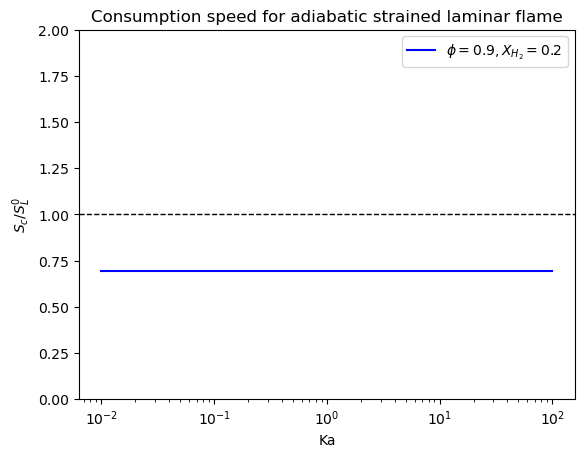

In [74]:
# Plot
plt.figure()
plt.plot(Ka_values, S_cF_values, label=r'$\phi=0.9, X_{H_2}=0.2$', color='blue')
plt.axhline(y=1, color='k', linestyle='--', linewidth=1)  # stagnation line
plt.xscale('log')
plt.title('Consumption speed for adiabatic strained laminar flame')
plt.xlabel('Ka')
plt.ylabel(r'$S_c/S_L^0$')
plt.ylim(0, 2)
plt.legend()
plt.show()